In [1]:
import torch
import sidechainnet as scn
from models.mim_net import MimNet
from scripts.visualize_3d import plot_real_vs_predicted

Matplotlib is building the font cache; this may take a moment.


Using device: cuda
SidechainNet(7, 30) was not found in ./sidechainnet_data.


Downloaded SidechainNet to ./sidechainnet_data/sidechainnet_casp7_30.pkl.
SidechainNet was loaded from ./sidechainnet_data/sidechainnet_casp7_30.pkl.
Inicjalizacja MimNet...
MimNet gotowy.


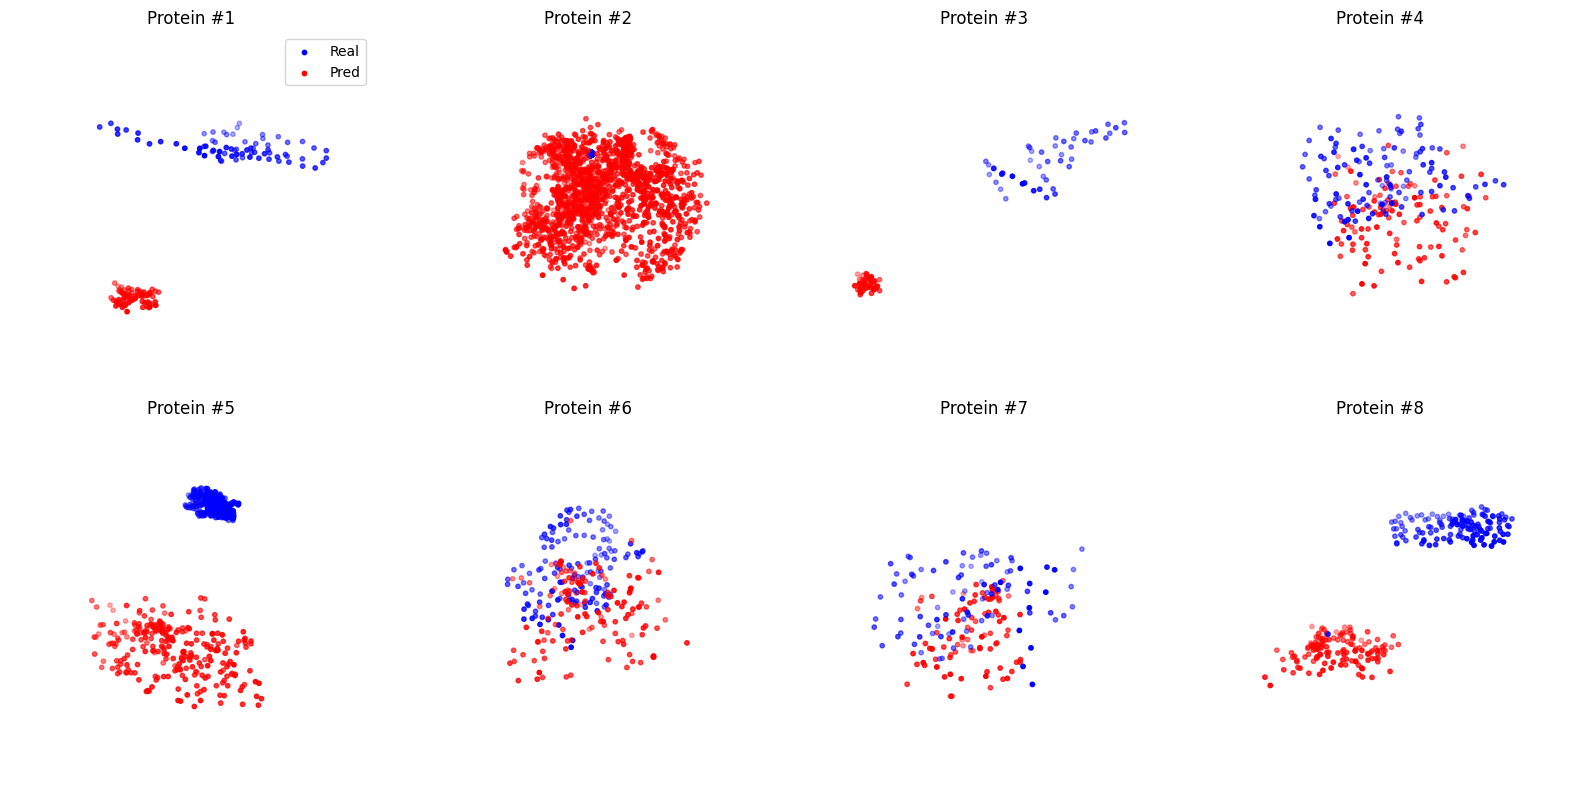

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
dataloaders = scn.load(casp_version=7, with_pytorch="dataloaders", batch_size=1)
test_loader = dataloaders["train"] # type: ignore

model = MimNet(in_channels=40, nf=128, T=6, n_levels=3).to(device)
checkpoint_path = "checkpoints/mimnet_model.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))

plot_real_vs_predicted(
    model=model, dataloader=test_loader, device=device
)